In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

ANALYTICS_DIR = "/content/drive/MyDrive/zepto-data-ai-platform/analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)

print("Analytics folder:", ANALYTICS_DIR)

Mounted at /content/drive
Analytics folder: /content/drive/MyDrive/zepto-data-ai-platform/analytics


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load Titanic dataset exactly once
df = sns.load_dataset("titanic")

# Immediately save raw dataset as offline fallback
TITANIC_PATH = f"{ANALYTICS_DIR}/titanic.csv"

df.to_csv(TITANIC_PATH, index=False)

print("Titanic dataset saved successfully!")
print("Shape:", df.shape)

df.head()

Titanic dataset saved successfully!
Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("========== DATASET INFO ==========")
df.info()

print("\n========== DESCRIBE ==========")
display(df.describe())

print("\n========== SHAPE ==========")
print(df.shape)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

========== DESCRIBE ==========


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



========== SHAPE ==========
(891, 15)


In [5]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

missing_table = missing_table[
    missing_table["Missing_Count"] > 0
]

display(missing_table)

,Missing_Count,Missing_Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [6]:
# Create a separate EDA-cleaned copy
df_clean = df.copy()

print("Missing percentages before cleaning:")
display(missing_table)


# ----------------------------------------------------
# 1. AGE: normally between 5% and 30%
# -> Median imputation
# ----------------------------------------------------

age_missing_pct = df_clean["age"].isnull().mean() * 100

if 5 <= age_missing_pct <= 30:
    age_median = df_clean["age"].median()
    df_clean["age"] = df_clean["age"].fillna(age_median)

    print(
        f"Age missing = {age_missing_pct:.2f}% "
        f"-> median imputation used ({age_median})."
    )


# ----------------------------------------------------
# 2. EMBARKED: normally less than 5%
# -> Drop affected rows
# ----------------------------------------------------

embarked_missing_pct = df_clean["embarked"].isnull().mean() * 100

if 0 < embarked_missing_pct < 5:
    df_clean = df_clean.dropna(subset=["embarked"])

    print(
        f"Embarked missing = {embarked_missing_pct:.2f}% "
        "-> affected rows dropped."
    )


# ----------------------------------------------------
# 3. EMBARK_TOWN: normally less than 5%
# -> Same affected rows can be removed
# ----------------------------------------------------

embark_town_missing_pct = df_clean["embark_town"].isnull().mean() * 100

if 0 < embark_town_missing_pct < 5:
    df_clean = df_clean.dropna(subset=["embark_town"])

    print(
        f"Embark_town missing = {embark_town_missing_pct:.2f}% "
        "-> affected rows dropped."
    )


# ----------------------------------------------------
# 4. DECK: very high missingness
# -> Drop column because reliable imputation is not appropriate
# ----------------------------------------------------

deck_missing_pct = df_clean["deck"].isnull().mean() * 100

if deck_missing_pct > 30:
    df_clean = df_clean.drop(columns=["deck"])

    print(
        f"Deck missing = {deck_missing_pct:.2f}% "
        "-> column dropped because missingness is too high "
        "for reliable imputation."
    )


print("\nCleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Missing percentages before cleaning:


,Missing_Count,Missing_Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


Age missing = 19.87% -> median imputation used (28.0).
Embarked missing = 0.22% -> affected rows dropped.
Deck missing = 77.39% -> column dropped because missingness is too high for reliable imputation.

Cleaned shape: (889, 14)

Remaining missing values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [7]:
CLEAN_PATH = f"{ANALYTICS_DIR}/titanic_cleaned.csv"

df_clean.to_csv(
    CLEAN_PATH,
    index=False
)

print("Cleaned Titanic saved:")
print(CLEAN_PATH)

Cleaned Titanic saved:
/content/drive/MyDrive/zepto-data-ai-platform/analytics/titanic_cleaned.csv


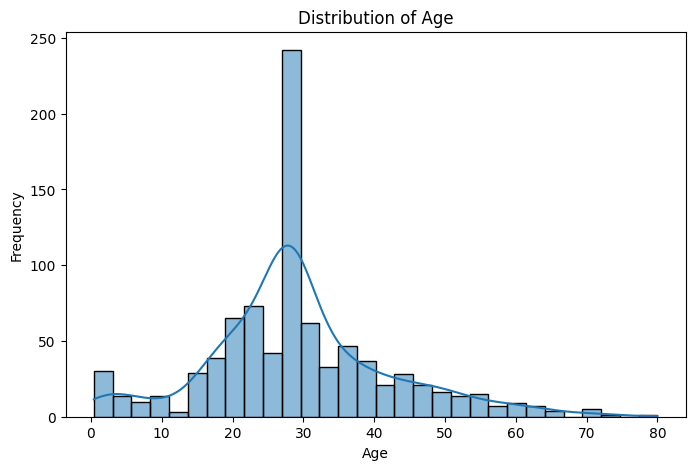

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["age"], kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

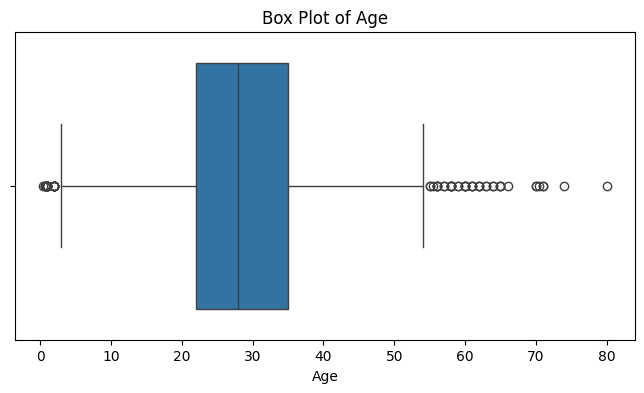

In [9]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()

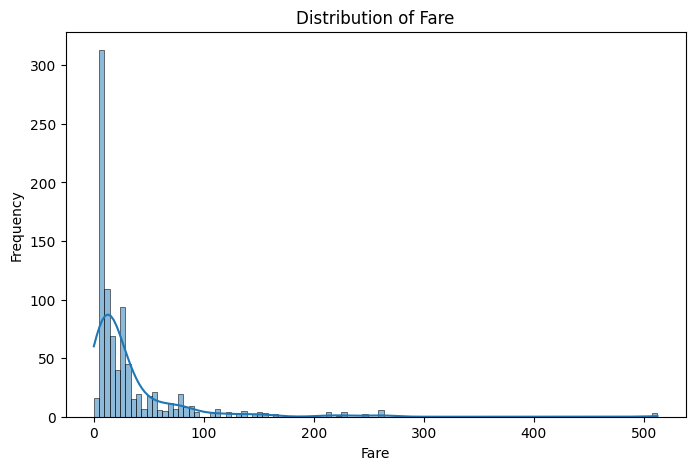

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean["fare"], kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

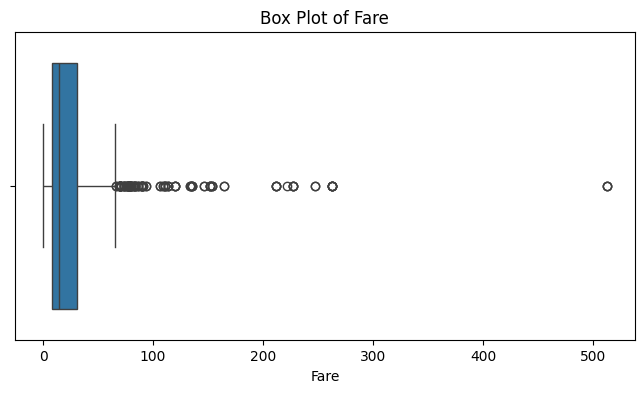

In [11]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [12]:
def count_iqr_outliers(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


age_results = count_iqr_outliers(df_clean["age"])
fare_results = count_iqr_outliers(df_clean["fare"])


print("AGE")
print("Q1:", age_results[0])
print("Q3:", age_results[1])
print("IQR:", age_results[2])
print("Lower Bound:", age_results[3])
print("Upper Bound:", age_results[4])
print("Number of Outliers:", age_results[5])


print("\nFARE")
print("Q1:", fare_results[0])
print("Q3:", fare_results[1])
print("IQR:", fare_results[2])
print("Lower Bound:", fare_results[3])
print("Upper Bound:", fare_results[4])
print("Number of Outliers:", fare_results[5])

AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Outliers: 65

FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Outliers: 114


In [13]:
fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]

print("Fare Mean:", round(fare_mean, 2))
print("Fare Median:", round(fare_median, 2))
print("Fare Mode:", round(fare_mode, 2))

if fare_mean > fare_median:
    print(
        "\nConclusion: Fare is right-skewed because "
        "the mean is greater than the median."
    )
elif fare_mean < fare_median:
    print(
        "\nConclusion: Fare is left-skewed because "
        "the mean is less than the median."
    )
else:
    print("\nConclusion: Fare is approximately symmetric.")

Fare Mean: 32.1
Fare Median: 14.45
Fare Mode: 8.05

Conclusion: Fare is right-skewed because the mean is greater than the median.


In [14]:
female_mask = df_clean["sex"] == "female"
male_mask = df_clean["sex"] == "male"

female_survival = df_clean.loc[
    female_mask, "survived"
].mean()

male_survival = df_clean.loc[
    male_mask, "survived"
].mean()

print(
    "Female survival rate:",
    round(female_survival * 100, 2),
    "%"
)

print(
    "Male survival rate:",
    round(male_survival * 100, 2),
    "%"
)

Female survival rate: 74.04 %
Male survival rate: 18.89 %


In [15]:
for pclass in [1, 2, 3]:

    mask = df_clean["pclass"] == pclass

    rate = df_clean.loc[
        mask,
        "survived"
    ].mean()

    print(
        f"Class {pclass} survival rate:",
        round(rate * 100, 2),
        "%"
    )

Class 1 survival rate: 62.62 %
Class 2 survival rate: 47.28 %
Class 3 survival rate: 24.24 %


In [16]:
for sex in ["female", "male"]:

    for pclass in [1, 2, 3]:

        mask = (
            (df_clean["sex"] == sex) &
            (df_clean["pclass"] == pclass)
        )

        rate = df_clean.loc[
            mask,
            "survived"
        ].mean()

        print(
            f"{sex.title()} - Class {pclass}:",
            round(rate * 100, 2),
            "%"
        )

Female - Class 1: 96.74 %
Female - Class 2: 92.11 %
Female - Class 3: 50.0 %
Male - Class 1: 36.89 %
Male - Class 2: 15.74 %
Male - Class 3: 13.54 %


In [17]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df_clean[
    corr_columns
].corr()

display(corr_matrix)

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


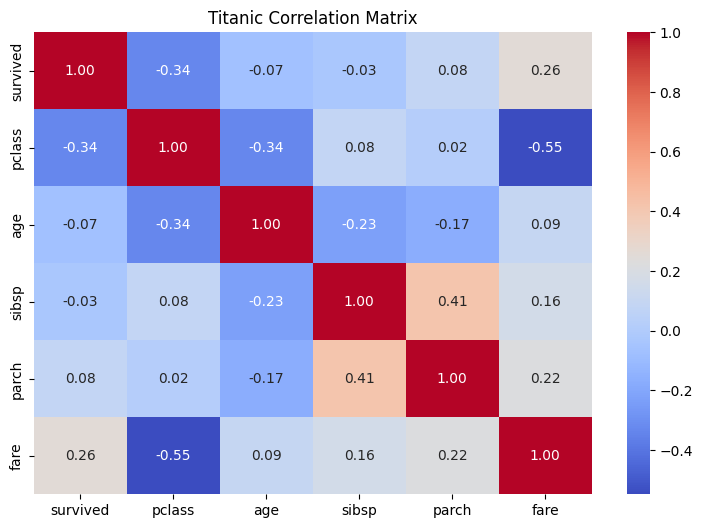

In [18]:
plt.figure(figsize=(9,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Titanic Correlation Matrix")

plt.show()

In [19]:
correlation_pairs = []

for i in range(len(corr_columns)):

    for j in range(i + 1, len(corr_columns)):

        col1 = corr_columns[i]
        col2 = corr_columns[j]

        value = corr_matrix.loc[
            col1,
            col2
        ]

        correlation_pairs.append(
            (col1, col2, value, abs(value))
        )


correlation_pairs = sorted(
    correlation_pairs,
    key=lambda x: x[3],
    reverse=True
)


top_two = correlation_pairs[:2]


print("Two strongest absolute correlations:")

for col1, col2, value, abs_value in top_two:

    print(
        f"{col1} vs {col2}: "
        f"{value:.3f}"
    )

Two strongest absolute correlations:
pclass vs fare: -0.548
sibsp vs parch: 0.415


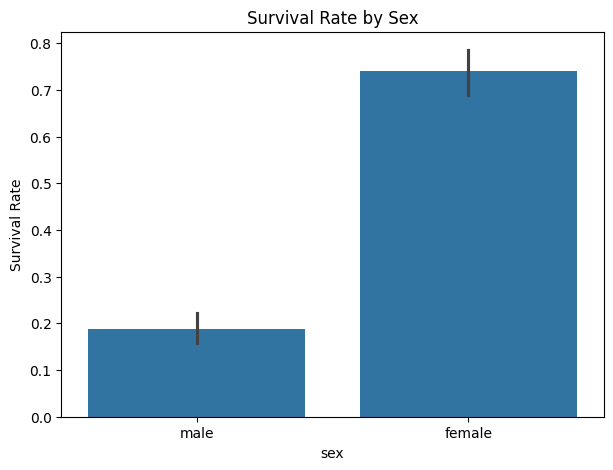

In [20]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_clean,
    x="sex",
    y="survived"
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation — Survival by Sex

The chart shows a clear difference in survival between male and female passengers.
Female passengers had a substantially higher survival rate than male passengers.
This suggests that sex was strongly associated with survival outcome on the Titanic.


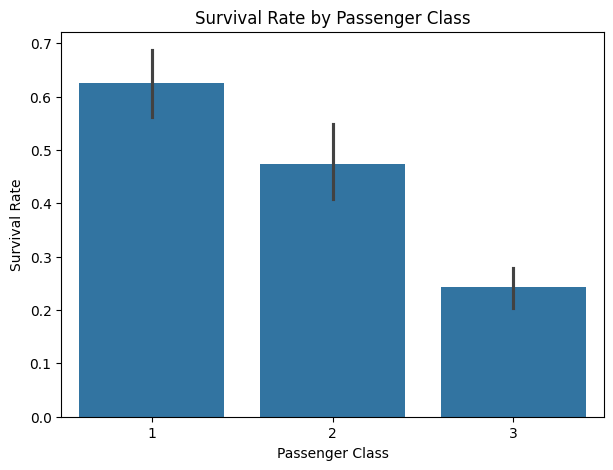

In [22]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation — Survival by Passenger Class

Survival rates varied considerably across passenger classes.
First-class passengers had a higher survival rate than passengers in lower classes.
This suggests that passenger class and the conditions associated with class influenced survival.

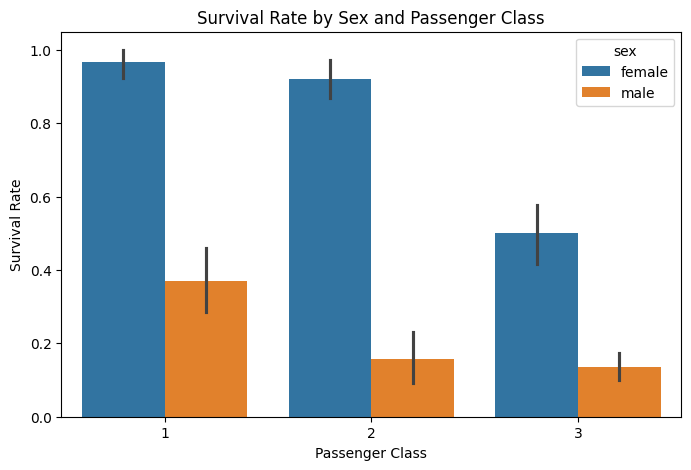

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

### Interpretation — Sex and Passenger Class

The combined chart shows that survival was related to both sex and passenger class.
Female passengers generally had higher survival rates across classes, while class also
created substantial differences within each sex. This indicates that survival patterns
cannot be explained by a single variable alone.

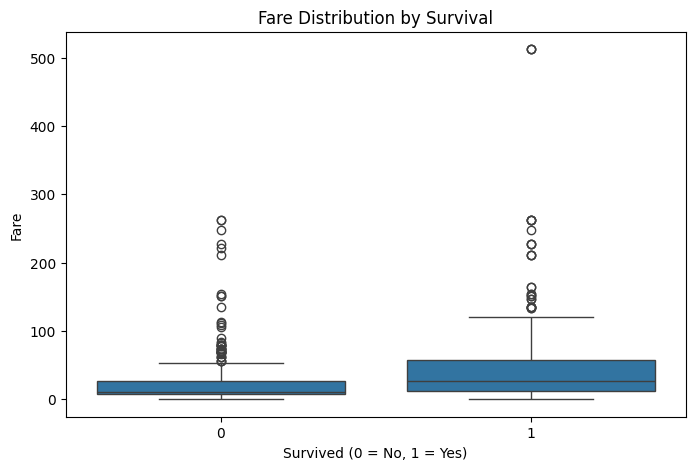

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

### Interpretation — Fare and Survival

Passengers who survived tended to have a higher fare distribution than passengers who did
not survive. Fare is closely related to passenger class, so this pattern is consistent with
the higher survival rates observed among higher-class passengers. The large spread and
outliers also show that fare is strongly right-skewed.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler_eda = StandardScaler()

scaled_values = scaler_eda.fit_transform(
    df_clean[["age", "fare"]]
)

df_scaled = pd.DataFrame(
    scaled_values,
    columns=[
        "age_standardized",
        "fare_standardized"
    ]
)

print("BEFORE STANDARDIZATION")

print(
    df_clean[["age", "fare"]]
    .agg(["mean", "std"])
)


print("\nAFTER STANDARDIZATION")

print(
    df_scaled
    .agg(["mean", "std"])
)

BEFORE STANDARDIZATION
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

AFTER STANDARDIZATION
      age_standardized  fare_standardized
mean      2.717486e-16       1.398706e-16
std       1.000563e+00       1.000563e+00


In [27]:
print("========== MODULE 2A EDA CHECK ==========")

print("Raw Titanic file exists:",
      os.path.exists(TITANIC_PATH))

print("Cleaned Titanic file exists:",
      os.path.exists(CLEAN_PATH))

print("Raw shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRequired correlation columns:")
print(corr_columns)

print("\nTwo strongest correlations:")
for pair in top_two:
    print(pair)

print("\nAge outliers:", age_results[5])
print("Fare outliers:", fare_results[5])

print("\nEDA SECTION COMPLETE")

========== MODULE 2A EDA CHECK ==========
Raw Titanic file exists: True
Cleaned Titanic file exists: True
Raw shape: (891, 15)
Cleaned shape: (889, 14)

Required correlation columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Two strongest correlations:
('pclass', 'fare', np.float64(-0.5481932852366449), np.float64(0.5481932852366449))
('sibsp', 'parch', np.float64(0.4145416380997264), np.float64(0.4145416380997264))

Age outliers: 65
Fare outliers: 114

EDA SECTION COMPLETE
